In [1]:
library(miloR)
library(ggplot2)
library(dplyr)
library(ggbeeswarm)

Loading required package: edgeR

Loading required package: limma


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
da_results <- read.csv('data/miloR/da_results_miloR.csv')

Converting group_by to factor...



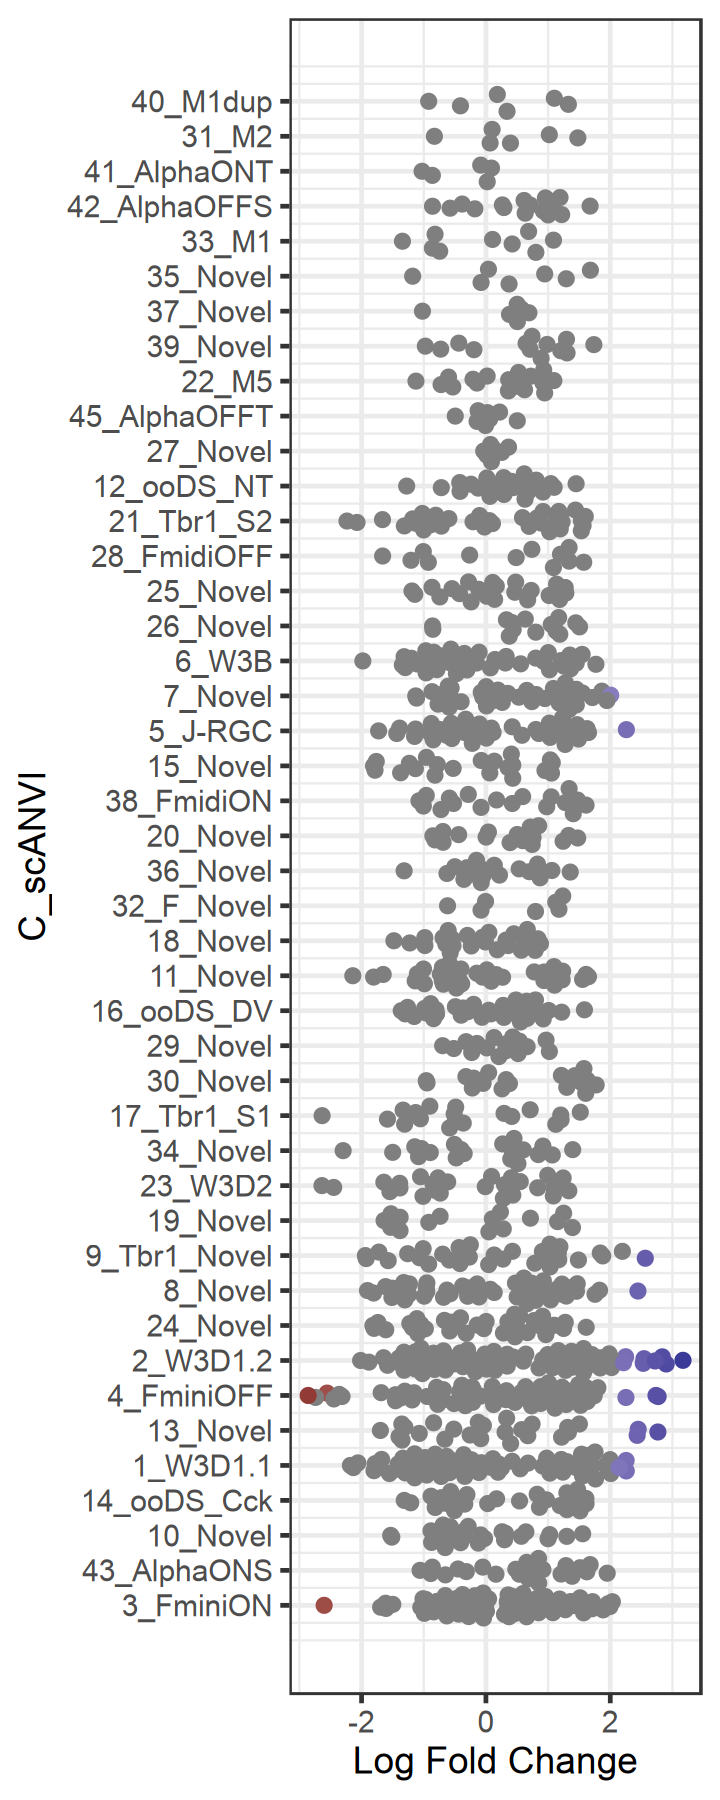

In [3]:
options(repr.plot.height = 15, repr.plot.width = 6) 
plotDAbeeswarm(da_results, group.by = "C_scANVI")

In [4]:
target_celltypes_info <- da_results %>%
  filter(SpatialFDR < 0.1) %>%
  group_by(C_scANVI) %>%
  summarise(mean_sig_lfc = mean(logFC, na.rm = TRUE), .groups = 'drop') %>%
  arrange(desc(mean_sig_lfc))
ordered_levels <- target_celltypes_info$C_scANVI

In [5]:
plot_data <- da_results %>%
  filter(C_scANVI %in% ordered_levels) %>%
  mutate(C_scANVI = factor(C_scANVI, levels = ordered_levels)) %>%
  mutate(color_val = ifelse(SpatialFDR < 0.1, logFC, NA))

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


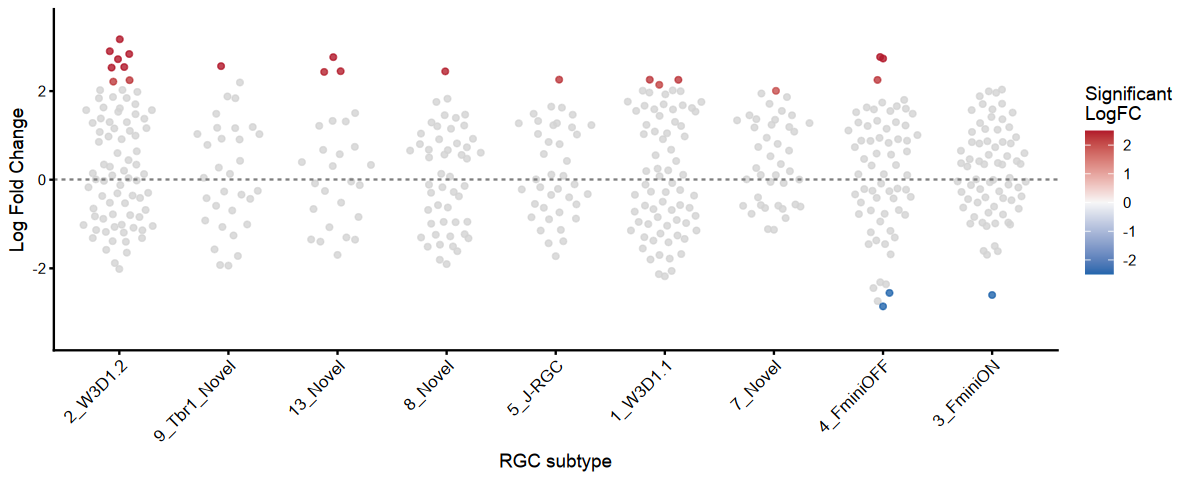

In [6]:
options(repr.plot.height = 4, repr.plot.width = 10) 
ggplot(plot_data, aes(x = C_scANVI, y = logFC, color = color_val)) +
  geom_quasirandom(size = 1.2, alpha = 0.8, width = 0.35) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey50") +
  scale_color_gradient2(
    low = "#2166ac", 
    mid = "#f7f7f7", 
    high = "#b2182b", 
    midpoint = 0,
    limits = c(-2.5, 2.5),oob = scales::squish,
    na.value = "#D3D3D3",
    name = "Significant\nLogFC"
  ) + coord_cartesian(ylim = c(-3.5, 3.5)) +
  labs(
    x = "RGC subtype",
    y = "Log Fold Change"
  ) +
  theme_classic() + 
  theme(
    axis.line = element_line(size = 0.5, color = "black"),
    axis.text.x = element_text(angle = 45, hjust = 1, color = "black", size = 10),
    axis.text.y = element_text(color = "black"),
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "right"
  )